In [54]:
import numpy as np
import gymnasium as gym
from itertools import product
from gymnasium.wrappers import RecordVideo
import matplotlib.pyplot as plt

In [55]:
class PolynomialBasis:
    def __init__(self, state_dim, degree):
        self.state_dim = state_dim
        self.degree = degree
        self.powers = self._generate_powers(state_dim, degree)
        self.num_features = len(self.powers)

    def _generate_powers(self, dim, degree):
        return [p for p in product(range(degree + 1), repeat=dim)]

    def get_features(self, state):
        return np.array([np.prod(state ** p) for p in self.powers])

In [56]:
class FourierBasis:
    def __init__(self, state_dim, order):
        self.state_dim = state_dim
        self.order = order
        self.num_features = (order + 1) ** state_dim
        self.c = np.array(np.meshgrid(*[range(order + 1)] * state_dim)).T.reshape(-1, state_dim)

    def get_features(self, state):
        # Assumes state is normalized to [0, 1]
        return np.cos(np.pi * np.dot(self.c, state))

In [57]:
class SarsaFunctionApprox:
    def __init__(self, env, degree=2, alpha=0.01, gamma=0.99, epsilon=0.1):
        self.env = env
        self.state_dim = env.observation_space.shape[0]
        self.num_actions = env.action_space.n
        self.basis = FourierBasis(self.state_dim, degree)
        self.num_features = self.basis.num_features
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.weights = np.zeros((self.num_actions, self.num_features))

    def normalize_state(self, state):
        # Clip to prevent infinities and normalize to [0, 1]
        low = self.env.observation_space.low
        high = self.env.observation_space.high

        # Clip to reasonable values for unbounded dimensions
        low = np.where(np.isfinite(low), low, -1.0)
        high = np.where(np.isfinite(high), high, 1.0)

        return (state - low) / (high - low)

    def get_q_values(self, state):
        norm_state = self.normalize_state(state)
        features = self.basis.get_features(norm_state)
        q_values = np.dot(self.weights, features)
        return q_values, features

    def choose_action(self, state):
        q_values, _ = self.get_q_values(state)
        if np.random.rand() < self.epsilon:
            return self.env.action_space.sample()
        return np.argmax(q_values)

    def train(self, episodes=1000):
        rewards = []

        for ep in range(episodes):
            state = self.env.reset()[0]
            action = self.choose_action(state)
            done = False
            total_reward = 0

            q_values, features = self.get_q_values(state)

            while not done:
                next_state, reward, done, _, info = self.env.step(action)
                total_reward += reward
                next_action = self.choose_action(next_state)
                next_q_values, next_features = self.get_q_values(next_state)

                td_target = reward + self.gamma * next_q_values[next_action] * (not done)
                td_error = td_target - q_values[action]
                self.weights[action] += self.alpha * td_error * features

                state, action, q_values, features = next_state, next_action, next_q_values, next_features

            rewards.append(total_reward)
            if (ep + 1) % 100 == 0:
                avg_reward = np.mean(rewards[-100:])
                print(f"Episode {ep + 1}, Average Reward (last 100): {avg_reward:.2f}")

        return rewards

In [58]:
def plot_rewards(rewards, window=50):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards, label='Episode Reward')
    
    if len(rewards) >= window:
        moving_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
        plt.plot(range(window - 1, len(rewards)), moving_avg, label=f'{window}-Episode Moving Avg', color='orange')
    
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title('SARSA with Polynomial Basis - Cart-pole')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Starting training...
Episode 100, Average Reward (last 100): 9.88
Episode 200, Average Reward (last 100): 10.02
Episode 300, Average Reward (last 100): 30.83
Episode 400, Average Reward (last 100): 167.17
Episode 500, Average Reward (last 100): 150.64
Episode 600, Average Reward (last 100): 134.57
Episode 700, Average Reward (last 100): 133.25
Episode 800, Average Reward (last 100): 137.09
Episode 900, Average Reward (last 100): 138.43
Episode 1000, Average Reward (last 100): 145.17
Episode 1100, Average Reward (last 100): 137.86
Episode 1200, Average Reward (last 100): 139.54
Episode 1300, Average Reward (last 100): 155.65
Episode 1400, Average Reward (last 100): 157.82
Episode 1500, Average Reward (last 100): 150.95
Episode 1600, Average Reward (last 100): 164.83
Episode 1700, Average Reward (last 100): 154.67
Episode 1800, Average Reward (last 100): 149.14
Episode 1900, Average Reward (last 100): 151.78
Episode 2000, Average Reward (last 100): 156.13


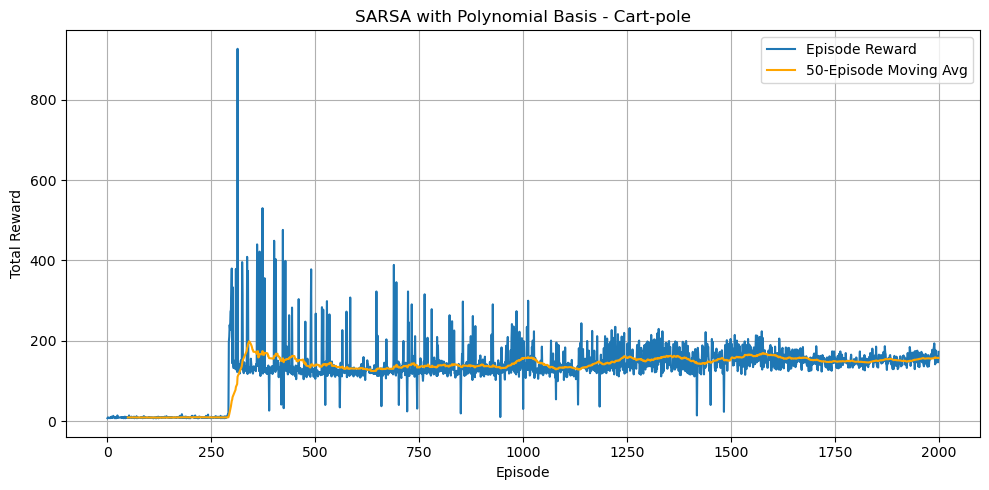


Rendering one episode...


c:\Users\anton\anaconda3\Lib\site-packages\gymnasium\wrappers\rendering.py:283: UserWarning: WARN: Overwriting existing videos at c:\Users\anton\Desktop\AA\aprendizagem por reforço\algoritmos de ar\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Rendered episode reward: 171.00


In [59]:
 # Create environment
env = gym.make('CartPole-v1')
    
# Initialize agent with polynomial basis of order 2
agent = SarsaFunctionApprox(env, degree=2, alpha=0.0005, gamma=0.99, epsilon=0.1)
    
# Train the agent
print("Starting training...")
training_rewards = agent.train(episodes=2000)
plot_rewards(training_rewards)
    
env.close()
    
# Render one episode
print("\nRendering one episode...")
env = gym.make('CartPole-v1', render_mode="rgb_array")
env = RecordVideo(env, './videos')
state = env.reset()[0]
done = False
total_reward = 0
    
while not done:
    action = agent.choose_action(state)
    state, reward, done, _, info = env.step(action)
    total_reward += reward
    env.render()
    
print(f"Rendered episode reward: {total_reward:.2f}")
env.close()